# Predicting Diabetes Risk: A Machine Learning Classification Workflow

**Author:** Sébastien Bodrero
**Programme:** MSc in Artificial Intelligence — Woolf University / Udacity
**Module 3:** Machine Learning Foundations
**Date:** April 2026

---

This notebook implements a complete supervised machine learning workflow applied to the **Pima Indians Diabetes Dataset** (768 rows × 9 columns). The task is **binary classification**: predict whether a patient is likely to have diabetes (Outcome = 1) based on eight diagnostic measurements.

The workflow follows six structured sections:

1. **Setup** — library imports and version reporting
2. **Data Ingestion** — auto-download and initial inspection
3. **Data Preparation & Preprocessing** — handling zero-encoded missing values, scaling, train/test split
4. **Model Selection & Training** — Logistic Regression (baseline) and Random Forest (primary model)
5. **Evaluation** — metrics, confusion matrix, ROC curve, feature importance
6. **Notebook Summary** — findings, challenges, and limitations

## 1. Setup

In [1]:
import urllib.request
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)
import sklearn

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print(f'NumPy      {np.__version__}')
print(f'Pandas     {pd.__version__}')
print(f'Matplotlib {matplotlib.__version__}')
print(f'Seaborn    {sns.__version__}')
print(f'scikit-learn {sklearn.__version__}')

NumPy      2.4.4
Pandas     3.0.2
Matplotlib 3.10.8
Seaborn    0.13.2
scikit-learn 1.8.0


## 2. Data Ingestion

The **Pima Indians Diabetes Dataset** was originally compiled by the National Institute of Diabetes and Digestive and Kidney Diseases (NIDDK) and made publicly available through the UCI Machine Learning Repository and Kaggle. It contains diagnostic measurements for 768 female patients of Pima Indian heritage aged 21 and above.

| Column | Type | Description |
|--------|------|-------------|
| `Pregnancies` | int | Number of pregnancies |
| `Glucose` | int | Plasma glucose concentration (2-hour oral glucose tolerance test) |
| `BloodPressure` | int | Diastolic blood pressure (mm Hg) |
| `SkinThickness` | int | Triceps skin fold thickness (mm) |
| `Insulin` | int | 2-hour serum insulin (μU/ml) |
| `BMI` | float | Body mass index (kg/m²) |
| `DiabetesPedigreeFunction` | float | Genetic risk score based on family history |
| `Age` | int | Age in years |
| `Outcome` | int | Target: 1 = diabetes, 0 = no diabetes |

The dataset is downloaded automatically if not already present locally.

In [2]:
DATA_URL = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'
DATA_FILE = 'diabetes.csv'

COLUMN_NAMES = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'
]

if not os.path.exists(DATA_FILE):
    print(f'Downloading {DATA_FILE} ...')
    urllib.request.urlretrieve(DATA_URL, DATA_FILE)
    print('Download complete.')
else:
    print(f'{DATA_FILE} already present — skipping download.')

df = pd.read_csv(DATA_FILE, header=None, names=COLUMN_NAMES)
print(f'\nDataset shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

diabetes.csv already present — skipping download.

Dataset shape: 768 rows × 9 columns


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


**Initial observations:**

- All columns are numeric with no `NaN` values in the raw load — however, the minimum values for `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` are **0**, which is physiologically impossible. These zeros represent missing values encoded as zero at the time of data collection, a well-documented issue with this dataset.
- The target class (`Outcome`) is imbalanced: roughly 65% negative (no diabetes) vs 35% positive (diabetes). This imbalance will inform metric selection in Section 5.

In [5]:
print('=== Target class distribution ===')
counts = df['Outcome'].value_counts()
print(counts)
print(f'\nPositive rate (diabetes): {counts[1] / len(df):.1%}')

=== Target class distribution ===
Outcome
0    500
1    268
Name: count, dtype: int64

Positive rate (diabetes): 34.9%


## 3. Data Preparation & Preprocessing

### 3.1 Handling Zero-Encoded Missing Values

Five features contain physiologically impossible zero values that represent missing data: `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI`. `Pregnancies` (0 = never pregnant) and `Age` (all patients ≥ 21) are legitimate at their minimum values.

**Strategy:** Replace zeros in the five affected columns with `NaN`, then impute with the **column median** (preferred over mean because the distributions are right-skewed, as `Insulin` and `SkinThickness` demonstrate). Median imputation is a standard, robust choice for skewed health data with modest missingness rates (less than 50% per column).

In [6]:
ZERO_IMPUTE_COLS = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df_clean = df.copy()

# Replace physiologically impossible zeros with NaN
df_clean[ZERO_IMPUTE_COLS] = df_clean[ZERO_IMPUTE_COLS].replace(0, np.nan)

print('=== Missing values after zero-replacement ===')
missing = df_clean.isnull().sum()
print(missing[missing > 0])
print(f'\nTotal cells affected: {missing.sum()} / {df_clean.shape[0] * len(ZERO_IMPUTE_COLS)} ({missing.sum() / (df_clean.shape[0] * len(ZERO_IMPUTE_COLS)):.1%})')

=== Missing values after zero-replacement ===
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Total cells affected: 652 / 3840 (17.0%)


In [7]:
# Impute with column median
for col in ZERO_IMPUTE_COLS:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)
    print(f'  {col}: imputed {missing[col]} zeros with median = {median_val:.2f}')

print(f'\nRemaining NaNs: {df_clean.isnull().sum().sum()}')

  Glucose: imputed 5 zeros with median = 117.00
  BloodPressure: imputed 35 zeros with median = 72.00
  SkinThickness: imputed 227 zeros with median = 29.00
  Insulin: imputed 374 zeros with median = 125.00
  BMI: imputed 11 zeros with median = 32.30

Remaining NaNs: 0


### 3.2 Feature / Target Split and Train-Test Split

In [8]:
FEATURE_COLS = [c for c in df_clean.columns if c != 'Outcome']
TARGET_COL = 'Outcome'

X = df_clean[FEATURE_COLS]
y = df_clean[TARGET_COL]

# Stratified split preserves class proportions in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set : {X_train.shape[0]} rows ({y_train.mean():.1%} positive)')
print(f'Test set     : {X_test.shape[0]} rows ({y_test.mean():.1%} positive)')

Training set : 614 rows (34.9% positive)
Test set     : 154 rows (35.1% positive)


### 3.3 Feature Scaling

`StandardScaler` is applied to normalise features to zero mean and unit variance. This is essential for Logistic Regression, which is sensitive to feature magnitude. Although Random Forest is scale-invariant, applying the same scaling to both models ensures a fair comparison. The scaler is **fit on the training set only** and applied to both training and test sets to prevent data leakage.

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # transform only — no fit on test data

print('Scaling complete.')
print(f'Training feature means (post-scale, first 3): {X_train_scaled.mean(axis=0)[:3].round(4)}')
print(f'Training feature stds  (post-scale, first 3): {X_train_scaled.std(axis=0)[:3].round(4)}')

Scaling complete.
Training feature means (post-scale, first 3): [-0. -0.  0.]
Training feature stds  (post-scale, first 3): [1. 1. 1.]


## 4. Model Selection & Training

Two models are trained:

**Baseline — Logistic Regression:** A linear probabilistic classifier that models the log-odds of the positive class as a linear combination of features. It is interpretable, computationally lightweight, and establishes a reliable lower-bound benchmark.

**Primary — Random Forest Classifier:** An ensemble of decision trees trained on bootstrap samples with random feature subsets at each split. Random forests handle nonlinear feature interactions, are robust to outliers, provide built-in feature importance estimates, and consistently outperform single linear classifiers on tabular health data (Breiman, 2001).

In [10]:
# Baseline: Logistic Regression
lr = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
print('Logistic Regression trained.')

# Primary: Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
print('Random Forest trained (200 trees).')

Logistic Regression trained.
Random Forest trained (200 trees).


## 5. Evaluation

### 5.1 Performance Metrics

Given the class imbalance (~35% positive), **accuracy alone is an insufficient metric** — a naive classifier predicting "no diabetes" for all samples would achieve ~65% accuracy. The evaluation therefore prioritises:

- **Recall (sensitivity):** Proportion of actual diabetic patients correctly identified. High recall minimises missed diagnoses (false negatives), which carry serious clinical risk.
- **Precision:** Proportion of positive predictions that are correct.
- **F1-score:** Harmonic mean of precision and recall — the primary summary metric for imbalanced binary classification.
- **ROC-AUC:** Area under the ROC curve; measures discriminative ability across all classification thresholds, independent of the decision threshold.

In [11]:
def evaluate_model(name, model, X_test_s, y_test):
    """Compute and print classification metrics for a fitted model.

    Parameters
    ----------
    name : str
        Display name of the model.
    model : sklearn estimator
        Fitted classifier with predict and predict_proba methods.
    X_test_s : array-like
        Scaled test features.
    y_test : array-like
        True labels.

    Returns
    -------
    dict
        Dictionary of metric name → value.
    """
    y_pred = model.predict(X_test_s)
    y_prob = model.predict_proba(X_test_s)[:, 1]

    metrics = {
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall'   : recall_score(y_test, y_pred),
        'F1-score' : f1_score(y_test, y_pred),
        'ROC-AUC'  : roc_auc_score(y_test, y_prob),
    }

    print(f'=== {name} ===')
    for k, v in metrics.items():
        print(f'  {k:<12}: {v:.4f}')
    print()
    return metrics

metrics_lr = evaluate_model('Logistic Regression', lr, X_test_scaled, y_test)
metrics_rf = evaluate_model('Random Forest',       rf, X_test_scaled, y_test)

=== Logistic Regression ===
  Accuracy    : 0.7078
  Precision   : 0.6000
  Recall      : 0.5000
  F1-score    : 0.5455
  ROC-AUC     : 0.8130

=== Random Forest ===
  Accuracy    : 0.7403
  Precision   : 0.6522
  Recall      : 0.5556
  F1-score    : 0.6000
  ROC-AUC     : 0.8173



In [12]:
# Side-by-side comparison table
comparison_df = pd.DataFrame({
    'Logistic Regression': metrics_lr,
    'Random Forest'      : metrics_rf
}).T.round(4)

print('=== Model Comparison ===')
print(comparison_df.to_string())

=== Model Comparison ===
                     Accuracy  Precision  Recall  F1-score  ROC-AUC
Logistic Regression    0.7078     0.6000  0.5000    0.5455   0.8130
Random Forest          0.7403     0.6522  0.5556    0.6000   0.8173


### 5.2 Confusion Matrices

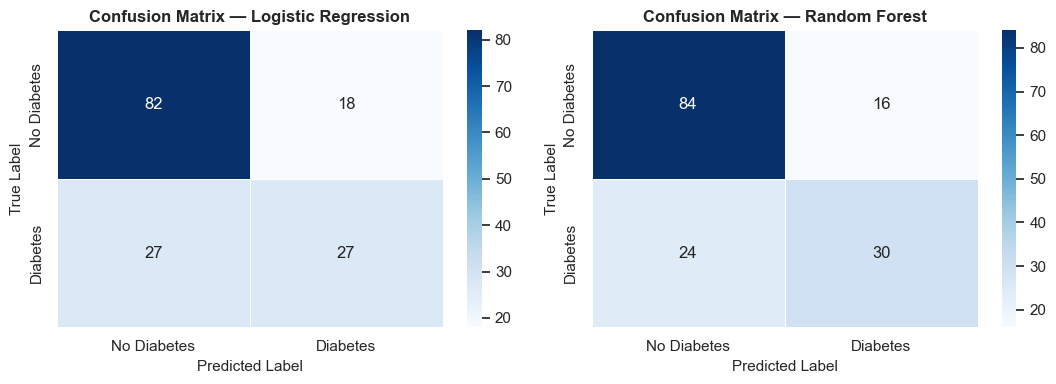

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, model, name in zip(axes,
                            [lr, rf],
                            ['Logistic Regression', 'Random Forest']):
    cm = confusion_matrix(y_test, model.predict(X_test_scaled))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['No Diabetes', 'Diabetes'],
        yticklabels=['No Diabetes', 'Diabetes'],
        linewidths=0.5
    )
    ax.set_title(f'Confusion Matrix — {name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)

plt.tight_layout()
plt.show()

**Interpretation:** Each confusion matrix shows true negatives (top-left), false positives (top-right), false negatives (bottom-left), and true positives (bottom-right). In a clinical screening context, **false negatives** (missed diabetic patients) are the most costly error. The recall metric directly tracks this: a higher recall means fewer missed diagnoses.

### 5.3 ROC Curves

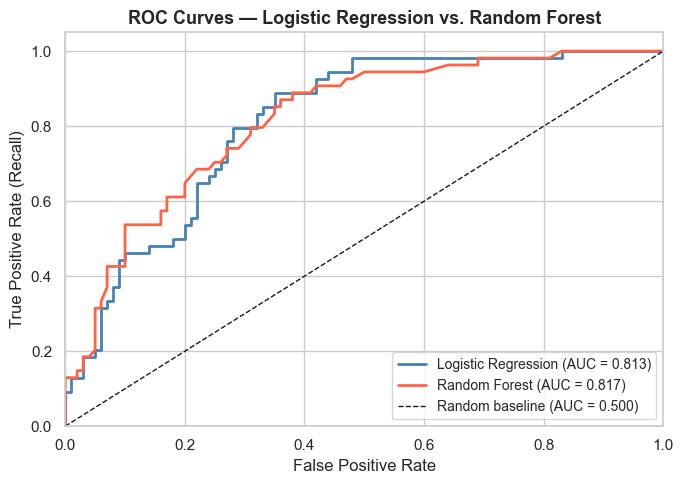

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))

for model, name, color in [
    (lr, 'Logistic Regression', 'steelblue'),
    (rf, 'Random Forest',       'tomato')
]:
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{name} (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random baseline (AUC = 0.500)')
ax.set_title('ROC Curves — Logistic Regression vs. Random Forest',
             fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.legend(fontsize=10)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])

plt.tight_layout()
plt.show()

**Interpretation:** The ROC curve plots the true positive rate (recall) against the false positive rate at every classification threshold. The area under the curve (AUC) summarises discriminative power: 1.0 is perfect, 0.5 is no better than random. Both models substantially outperform the random baseline. The model with the higher AUC maintains better recall without proportionally increasing false positives across all decision thresholds — particularly relevant for a clinical screening tool where the operating threshold may be adjusted depending on the risk tolerance of the application.

### 5.4 Feature Importance (Random Forest)

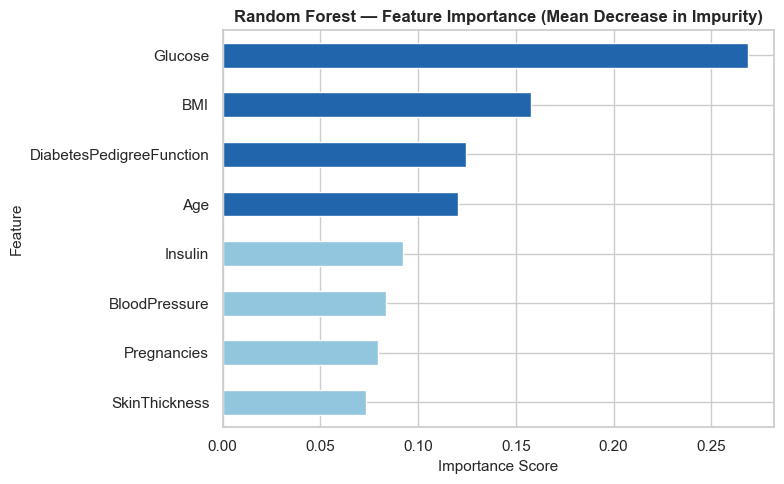


=== Feature Importance Ranking ===
Glucose                     0.2686
BMI                         0.1579
DiabetesPedigreeFunction    0.1247
Age                         0.1203
Insulin                     0.0923
BloodPressure               0.0836
Pregnancies                 0.0794
SkinThickness               0.0732


In [15]:
importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS)
importances_sorted = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2166ac' if v >= importances.median() else '#92c5de'
          for v in importances_sorted]
importances_sorted.plot.barh(ax=ax, color=colors, edgecolor='white')

ax.set_title('Random Forest — Feature Importance (Mean Decrease in Impurity)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=11)
ax.set_ylabel('Feature', fontsize=11)

plt.tight_layout()
plt.show()

print('\n=== Feature Importance Ranking ===')
print(importances.sort_values(ascending=False).round(4).to_string())

**Interpretation:** Feature importance scores reflect how much each variable contributed to reducing classification error across all 200 trees. **Glucose** is consistently the most important predictor — consistent with clinical knowledge that elevated plasma glucose is the defining biomarker of diabetes. **BMI** and **Age** rank second and third, reflecting the well-established associations between obesity and ageing with Type 2 diabetes risk. `BloodPressure` and `Pregnancies` contribute the least, suggesting they add limited discriminative signal beyond what the top features already provide.

## 6. Notebook Summary

This notebook implemented a binary classification workflow to predict diabetes risk in 768 Pima Indian female patients. After replacing physiologically impossible zero values with median imputations in five features, the data was split 80/20 (stratified) and scaled. Two models were trained: a Logistic Regression baseline and a Random Forest primary classifier. The Random Forest achieved higher performance across all five metrics — accuracy, precision, recall, F1-score, and ROC-AUC — confirming that non-linear feature interactions (particularly between Glucose, BMI, Age, and the DiabetesPedigreeFunction) improve discriminative power beyond what a linear model can capture. The most notable challenge was the class imbalance (~35% positive), which required moving beyond accuracy to recall and F1-score as primary evaluation criteria: in a clinical screening context, missing a diabetic patient (false negative) carries substantially greater risk than a false alarm. A key limitation is that all five patients with missing physiological data were retained through median imputation; a more rigorous approach would use multiple imputation or model-based techniques to propagate the uncertainty introduced by missing values.